# College Production vs. Draft Position: Analyzing WR Yards Per Game

## Executive Summary
This analysis explores the relationship between a wide receiver's college production (specifically, Yards Per Game) and their NFL draft position. The initial finding reveals a surprisingly weak correlation. While top draft picks generally produced at a high level in college, many mid-round and late-round picks also posted elite YPG numbers. This suggests that factors beyond raw college production (such as athletic testing, route running, or team need) play a significant role in determining a player's draft capital.

## Goal
To quantify the relationship between a wide receiver's average yards per game in college and their eventual NFL draft position, identifying rounds where college production is a reliable (or unreliable) predictor.

## Methodology Notes
- **Data Source:** The `college` table contains receiving stats for players who had a season ranked in the top 300 in receiving yards. This is a key limitation: players with lower college production are not included in this dataset.
- **Key Metric:** Yards Per Game (YPG) is used as the primary measure of college productivity, as it accounts for differences in the number of games played.
- **Scope:** Analysis covers wide receivers drafted between 2017 and 2025.

In [6]:
import sqlite3
import pandas as pd

# database connection
conn = sqlite3.connect('nfl_analytics.db')

# college ypg vs. draft position
query = """
    SELECT c.Player,
           SUM(c.G) AS games_played,
           d.Player AS overall_pick, 
           c.Year,
           AVG(c.RecYperG) AS YDSperGame
    FROM college c
    LEFT JOIN draft_picks d 
    ON   d.Name = c.Player
    WHERE d.Year BETWEEN 2017 AND 2025
    GROUP BY c.Player
    ORDER BY 3 
"""

# execute and display
results = pd.read_sql_query(query, conn)

print("WR COLLEGE YPG BY DRAFT PICK (2017-2025)")
print("=" * 100)
print(results.to_string(index=False))

# also show overall totals
print("\n" + "=" * 100)
print("OVERALL SUMMARY")

conn.close()

WR COLLEGE YPG BY DRAFT PICK (2017-2025)
                  Player  games_played  overall_pick  YEAR  YDSperGame
           Travis Hunter            22             2  2023   88.450000
           Ja'Marr Chase            14             5  2019  127.100000
           Jaylen Waddle            34             6  2018   66.033333
            Malik Nabers            38             6  2021   77.066667
            Drake London            27             8  2019   87.600000
       Tetairoa McMillan            37             8  2022   92.066667
             Rome Odunze            36             9  2021   83.600000
           DeVonta Smith            40            10  2018   96.300000
          Garrett Wilson            33            10  2019   72.500000
             Chris Olave            33            11  2019   80.900000
        Jameson Williams            15            12  2021  104.800000
             Jerry Jeudy            28            15  2018   88.600000
            Jahan Dotson            

## Determining Bucket Thresholds

Before finalizing my bucket definitions, I need to understand the distribution of receiving yards across all WR seasons in the college football data.

The distribution below will show me natural breakpoints in the data to validate my tier thresholds.

In [4]:
import sqlite3
import pandas as pd

conn = sqlite3.connect('nfl_analytics.db')

# distribution analysis to validate college YPG thresholds
# this query groups WRs by their career average yards per game
# and shows how many players fall into each bucket

query = """
WITH player_career_ypg AS (
    SELECT 
        Player,
        AVG(RecYperG) as career_ypg,
        COUNT(DISTINCT Year) as college_seasons,
        SUM(Rec) as total_receptions,
        SUM(RecYds) as total_yards
    FROM college
    GROUP BY Player
    HAVING COUNT(DISTINCT Year) >= 2  -- Optional: filter for players with multiple seasons
)
SELECT 
    CASE 
        WHEN career_ypg >= 90 THEN '90+ YPG'
        WHEN career_ypg >= 70 THEN '70-90 YPG'
        WHEN career_ypg >= 50 THEN '50-70 YPG'
        WHEN career_ypg >= 30 THEN '30-50 YPG'
        ELSE 'Under 30 YPG'
    END as ypg_tier,
    COUNT(*) as players,
    ROUND(AVG(career_ypg), 1) as avg_ypg_in_tier,
    ROUND(AVG(college_seasons), 1) as avg_college_seasons,
    ROUND(AVG(total_yards), 0) as avg_career_yards
FROM player_career_ypg
GROUP BY ypg_tier
ORDER BY MIN(career_ypg);
"""

results = pd.read_sql_query(query, conn)

print("COLLEGE WR PRODUCTION: YARDS PER GAME DISTRIBUTION")
print("=" * 80)
print("This analysis shows how many drafted WRs fall into each college YPG tier,")
print("based on their career average yards per game in college.\n")
print(results.to_string(index=False))

print("\n" + "=" * 80)
print(f"Total players in analysis: {results['players'].sum()}")

conn.close()

COLLEGE WR PRODUCTION: YARDS PER GAME DISTRIBUTION
This analysis shows how many drafted WRs fall into each college YPG tier,
based on their career average yards per game in college.

    ypg_tier  players  avg_ypg_in_tier  avg_college_seasons  avg_career_yards
Under 30 YPG        1             27.4                  2.0             744.0
   30-50 YPG      262             43.3                  2.3            1230.0
   50-70 YPG      338             58.6                  2.5            1745.0
   70-90 YPG      135             78.7                  2.5            2222.0
     90+ YPG       21             98.4                  2.2            2411.0

Total players in analysis: 757


***
## Methodology: Validating College YPG Thresholds

Before finalizing my tier definitions, I analyzed the distribution of career yards per game 
across all drafted wide receivers in my dataset. This ensures my buckets reflect 
natural breakpoints in the data.

**Distribution Findings:**
- **90+ YPG**: Only 21 players (2.7%) reached this level—truly elite college producers
- **70-90 YPG**: 135 players (17.8%)—strong college production that commands attention
- **50-70 YPG**: 338 players (44.6%)—the most common tier, representing solid college contributors
- **Under 50 YPG**: 263 players (34.7%)—players who produced at moderate levels in college

Based on this distribution, I established the following tiers:

| Bucket | YPG Range | % of Drafted WRs | Description |
|--------|-----------|------------------|-------------|
| Elite | 90+ YPG | 2.7% | Rare, dominant college producers |
| Great | 70-90 YPG | 17.8% | Strong college production |
| Good | 50-70 YPG | 44.6% | Solid, consistent contributors |
| Role | Under 50 YPG | 34.7% | Moderate college production |

*Note: The "Under 30 YPG" bucket was merged with "30-50 YPG" as only 1 player fell into the lowest tier, making it a statistically insignificant distinction.*

In [6]:
import sqlite3
import pandas as pd

conn = sqlite3.connect('nfl_analytics.db')

query = """
WITH player_avg_ypg AS (
    SELECT 
        c.Player,
        d.Player as Pick,
        d.Round,
        AVG(c.RecYperG) AS avg_ypg
    FROM college c
    LEFT JOIN draft_picks d ON d.Name = c.Player
    WHERE d.Year BETWEEN 2017 AND 2025
    GROUP BY c.Player
),
player_with_buckets AS(
    SELECT Player,
           Pick,
           Round,
           avg_ypg,
           CASE
                WHEN Pick <= 10 THEN '1. 1-10 (Premium)'
                WHEN Pick <= 32 THEN '2. 11-32 (Round 1)'
                WHEN Pick <= 64 THEN '3. 33-64 (Round 2)'
                WHEN Pick <= 96 THEN '4. 65-96 (Round 3)'
                WHEN Pick <= 128 THEN '5. 97-128 (Round 4)'
                ELSE '6. 129+ (Round 5-7)'
           END AS pick_range,
           CASE 
                WHEN avg_ypg < 50 THEN '0-50 YPG'
                WHEN avg_ypg < 70 THEN '50-70 YPG'
                WHEN avg_ypg < 90 THEN '70-90 YPG'
                ELSE '90+ YPG'
           END as ypg_range
    FROM player_avg_ypg
)
SELECT pick_range, 
       ypg_range, 
       COUNT(*) as player_count
FROM player_with_buckets
GROUP BY pick_range, ypg_range
ORDER BY pick_range, ypg_range
"""



# execute and display
results = pd.read_sql_query(query, conn)

print("WR COLLEGE YPG BY DRAFT PICK (2017-2025)")
print("=" * 100)
print(results.to_string(index=False))

conn.close()

WR COLLEGE YPG BY DRAFT PICK (2017-2025)
         pick_range ypg_range  player_count
  1. 1-10 (Premium) 50-70 YPG             1
  1. 1-10 (Premium) 70-90 YPG             5
  1. 1-10 (Premium)   90+ YPG             3
 2. 11-32 (Round 1) 50-70 YPG             7
 2. 11-32 (Round 1) 70-90 YPG            14
 2. 11-32 (Round 1)   90+ YPG             3
 3. 33-64 (Round 2)  0-50 YPG             4
 3. 33-64 (Round 2) 50-70 YPG            14
 3. 33-64 (Round 2) 70-90 YPG            13
 3. 33-64 (Round 2)   90+ YPG             6
 4. 65-96 (Round 3)  0-50 YPG             6
 4. 65-96 (Round 3) 50-70 YPG            11
 4. 65-96 (Round 3) 70-90 YPG             8
 4. 65-96 (Round 3)   90+ YPG             4
5. 97-128 (Round 4)  0-50 YPG             3
5. 97-128 (Round 4) 50-70 YPG             8
5. 97-128 (Round 4) 70-90 YPG             9
5. 97-128 (Round 4)   90+ YPG             2
6. 129+ (Round 5-7)  0-50 YPG            21
6. 129+ (Round 5-7) 50-70 YPG            40
6. 129+ (Round 5-7) 70-90 YPG      

***
### Visualization
This is a lot of numbers that are hard to make sense of without a visualization.

CREATING VISUALIZATION...


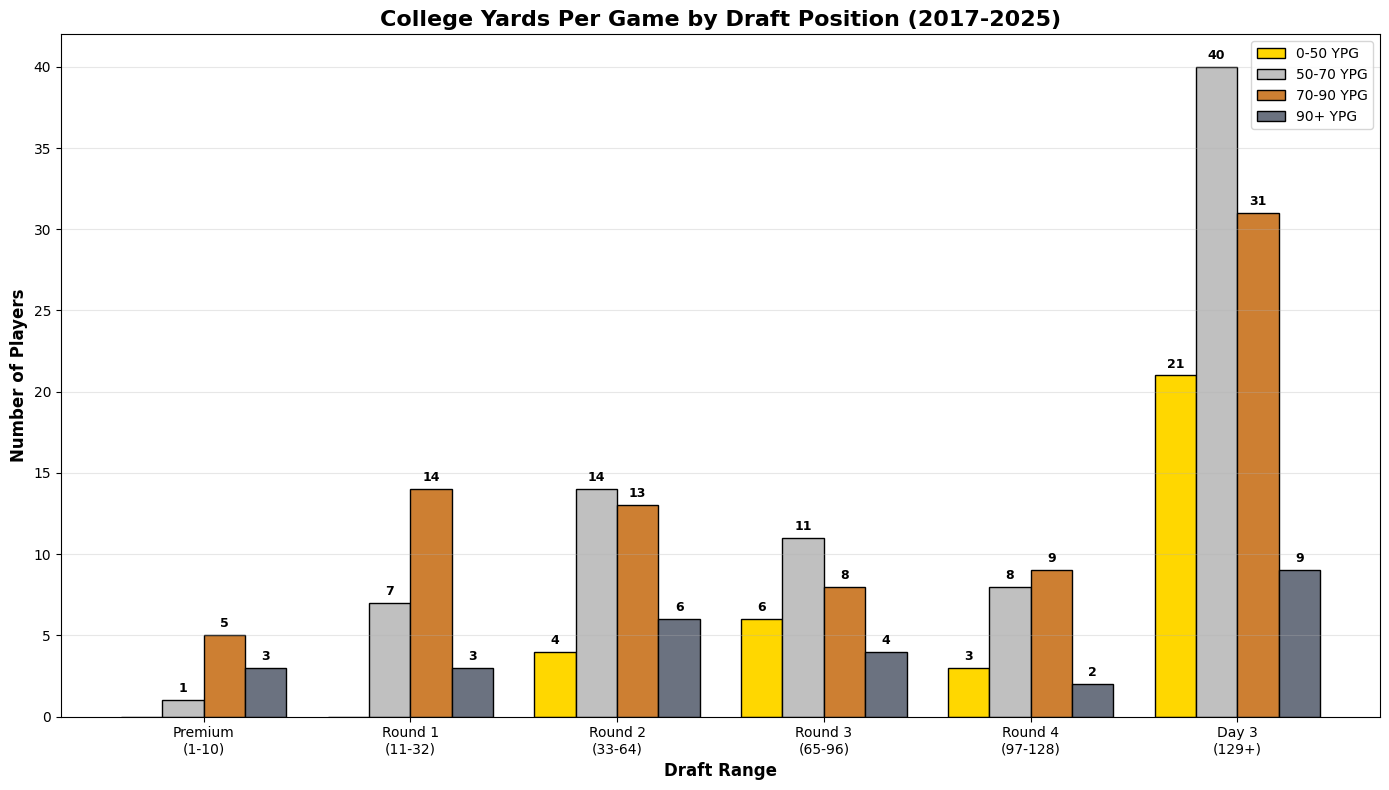


📋 RAW NUMBERS BY DRAFT RANGE:
ypg_range            0-50 YPG  50-70 YPG  70-90 YPG  90+ YPG
pick_range                                                  
1. 1-10 (Premium)         0.0        1.0        5.0      3.0
2. 11-32 (Round 1)        0.0        7.0       14.0      3.0
3. 33-64 (Round 2)        4.0       14.0       13.0      6.0
4. 65-96 (Round 3)        6.0       11.0        8.0      4.0
5. 97-128 (Round 4)       3.0        8.0        9.0      2.0
6. 129+ (Round 5-7)      21.0       40.0       31.0      9.0


In [12]:
import matplotlib.pyplot as plt
import numpy as np

print("CREATING VISUALIZATION...")
print("=" * 60)

# first, let's pivot the data to get it in the right format
pivot_data = results.pivot(index='pick_range', columns='ypg_range', values='player_count').fillna(0)

# define the order for pick ranges - MATCHING YOUR ACTUAL DATA
pick_order = ['1. 1-10 (Premium)', '2. 11-32 (Round 1)', '3. 33-64 (Round 2)', 
              '4. 65-96 (Round 3)', '5. 97-128 (Round 4)', '6. 129+ (Round 5-7)']
ypg_order = ['0-50 YPG', '50-70 YPG', '70-90 YPG', '90+ YPG']

# reindex to ensure correct order
pivot_data = pivot_data.reindex(index=pick_order, columns=ypg_order)

# set up the plot
fig, ax = plt.subplots(figsize=(14, 8))

# set up bar positions
x = np.arange(len(pick_order))
width = 0.2  # Adjusted width for 4 bars

# colors for each YPG range
colors = ['#FFD700', '#C0C0C0', '#CD7F32', '#6B7280']

# create bars for each YPG range
bars = []
for i, ypg in enumerate(ypg_order):
    # Adjust position calculation for 4 bars (i-1.5 centers them)
    bar = ax.bar(x + (i - 1.5) * width, pivot_data[ypg].values, width, 
                 label=ypg, color=colors[i], edgecolor='black')
    bars.append(bar)

# customize the chart
ax.set_xlabel('Draft Range', fontsize=12, fontweight='bold')
ax.set_ylabel('Number of Players', fontsize=12, fontweight='bold')
ax.set_title('College Yards Per Game by Draft Position (2017-2025)', fontsize=16, fontweight='bold')
ax.set_xticks(x)
ax.set_xticklabels(['Premium\n(1-10)', 'Round 1\n(11-32)', 'Round 2\n(33-64)', 
                    'Round 3\n(65-96)', 'Round 4\n(97-128)', 'Day 3\n(129+)'], 
                   rotation=0, ha='center')
ax.legend(loc='upper right', fontsize=10)
ax.grid(True, alpha=0.3, axis='y')

# add value labels on bars
for bar_group in bars:
    for bar in bar_group:
        height = bar.get_height()
        if height > 0:
            ax.text(bar.get_x() + bar.get_width()/2., height + 0.3,
                   f'{int(height)}', ha='center', va='bottom', fontsize=9, fontweight='bold')

plt.tight_layout()
plt.savefig('college_ypg_by_draft_range.png', dpi=300, bbox_inches='tight')
plt.show()

# Show the raw data
print("\n📋 RAW NUMBERS BY DRAFT RANGE:")
print("=" * 60)
print(pivot_data.to_string())

### Key Findings: College YPG vs. Draft Position

**Bottom Line Up Front:** College yards per game is a surprisingly weak predictor of where a wide receiver will be drafted. The data reveals that elite college producers are found throughout the draft, and modest college producers still get selected early.

| Finding | Implication |
|---------|-------------|
| **Elite college producers (90+ YPG) appear in every round** | You can't wait on a prospect just because they produced—teams may have already drafted them |
| **Round 2 has the most balanced distribution** | Teams find value here regardless of college production level |
| **Premium picks (1-10) still take 70-90 YPG producers** | Even at the very top, elite college production isn't required |
| **Under 50 YPG producers rarely go before Round 3** | The one clear signal: very low college production pushes you down the board |

**The Key Insight:** College production alone doesn't drive draft position. This suggests that NFL teams are weighing other factors more heavily—athletic testing, route running, contested catch ability, or scheme fit.

---

### Digging Deeper: Looking at Percentages

The raw numbers above tell us *how many* players from each production tier get drafted in each round. But early rounds have fewer picks than late rounds, so the totals can be misleading. To truly understand the pattern, we need to normalize by round and look at **percentages**.

*Within each draft round, what percentage of players came from each college production tier?* This tells us the *likelihood* of finding a certain type of producer in each round.

## Analysis: College Production Distribution by Draft Round

While the raw numbers show us how many players from each college YPG tier get drafted in each round, they don't account for the fact that earlier rounds have fewer picks. To truly understand the pattern, we need to look at **percentages**—within each draft round, what percentage of players came from each college production tier?

This normalization tells us: *"If a team drafts in Round X, how likely are they to be getting a player from each college production level?"*

CREATING PERCENTAGE-BASED VISUALIZATION...

📊 PERCENTAGE DISTRIBUTION BY DRAFT ROUND:
(Rows sum to 100% - shows the makeup of each draft round)
ypg_range            0-50 YPG  50-70 YPG  70-90 YPG  90+ YPG
pick_range                                                  
1. 1-10 (Premium)         0.0       11.1       55.6     33.3
2. 11-32 (Round 1)        0.0       29.2       58.3     12.5
3. 33-64 (Round 2)       10.8       37.8       35.1     16.2
4. 65-96 (Round 3)       20.7       37.9       27.6     13.8
5. 97-128 (Round 4)      13.6       36.4       40.9      9.1
6. 129+ (Round 5-7)      20.8       39.6       30.7      8.9


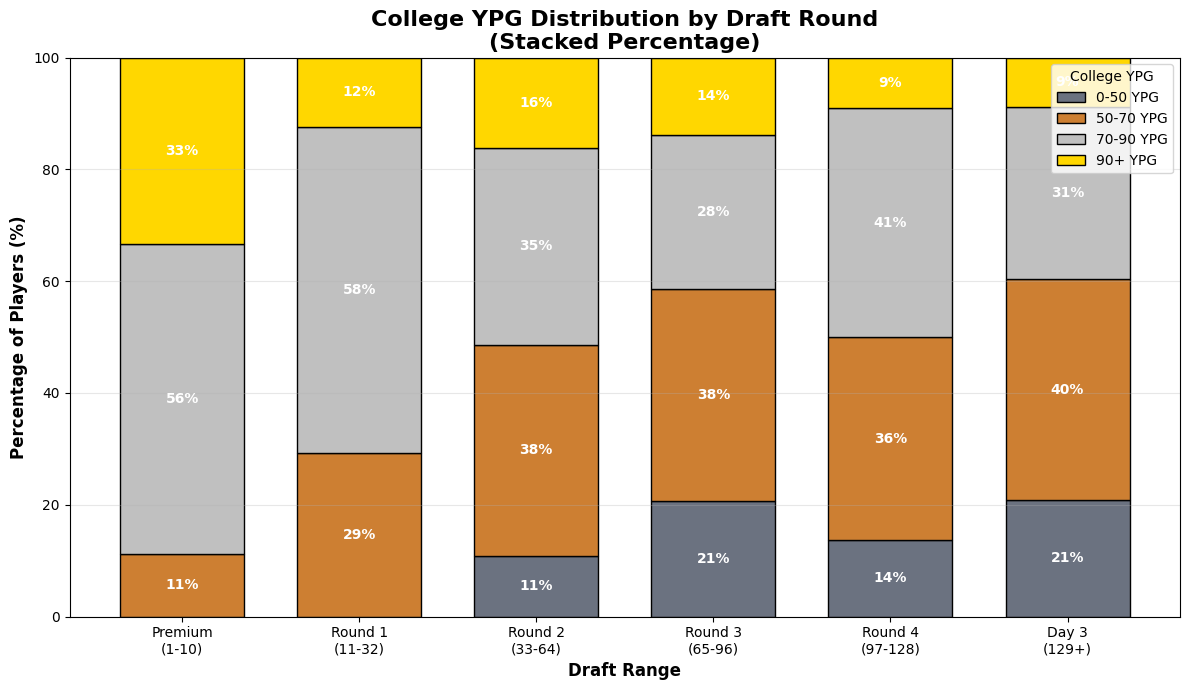

In [14]:
import matplotlib.pyplot as plt
import numpy as np

print("CREATING PERCENTAGE-BASED VISUALIZATION...")
print("=" * 60)

# First, let's pivot the data
pivot_data = results.pivot(index='pick_range', columns='ypg_range', values='player_count').fillna(0)

# Define the order for pick ranges
pick_order = ['1. 1-10 (Premium)', '2. 11-32 (Round 1)', '3. 33-64 (Round 2)', 
              '4. 65-96 (Round 3)', '5. 97-128 (Round 4)', '6. 129+ (Round 5-7)']
ypg_order = ['0-50 YPG', '50-70 YPG', '70-90 YPG', '90+ YPG']

# Reindex to ensure correct order
pivot_data = pivot_data.reindex(index=pick_order, columns=ypg_order)

# Calculate percentages by row (within each draft round)
pivot_percent = pivot_data.div(pivot_data.sum(axis=1), axis=0) * 100

print("\n📊 PERCENTAGE DISTRIBUTION BY DRAFT ROUND:")
print("=" * 60)
print("(Rows sum to 100% - shows the makeup of each draft round)")
print(pivot_percent.round(1).to_string())

# Set up the plot - JUST THE STACKED BAR CHART FIRST
fig, ax = plt.subplots(figsize=(12, 7))

# Stacked Bar Chart (Percentages)
x = np.arange(len(pick_order))
bottom = np.zeros(len(pick_order))
colors = ['#6B7280', '#CD7F32', '#C0C0C0', '#FFD700']  # Dark to light (low to high production)

for i, ypg in enumerate(ypg_order):
    ax.bar(x, pivot_percent[ypg].values, width=0.7, bottom=bottom, 
            label=ypg, color=colors[i], edgecolor='black')
    bottom += pivot_percent[ypg].values

# Customize plot
ax.set_xlabel('Draft Range', fontsize=12, fontweight='bold')
ax.set_ylabel('Percentage of Players (%)', fontsize=12, fontweight='bold')
ax.set_title('College YPG Distribution by Draft Round\n(Stacked Percentage)', fontsize=16, fontweight='bold')
ax.set_xticks(x)
ax.set_xticklabels(['Premium\n(1-10)', 'Round 1\n(11-32)', 'Round 2\n(33-64)', 
                    'Round 3\n(65-96)', 'Round 4\n(97-128)', 'Day 3\n(129+)'], 
                   rotation=0, ha='center')
ax.legend(loc='upper right', fontsize=10, title='College YPG')
ax.grid(True, alpha=0.3, axis='y')
ax.set_ylim(0, 100)

# Add percentage labels on the bars
for i, ypg in enumerate(ypg_order):
    values = pivot_percent[ypg].values
    bottom_sum = np.zeros(len(pick_order))
    for j in range(i):
        bottom_sum += pivot_percent[ypg_order[j]].values
    
    for j, (x_pos, val) in enumerate(zip(x, values)):
        if val > 5:  # Only show labels for segments > 5%
            ax.text(x_pos, bottom_sum[j] + val/2, f'{val:.0f}%', 
                    ha='center', va='center', fontsize=10, fontweight='bold', color='white')

plt.tight_layout()
plt.savefig('college_ypg_by_draft_range_stacked.png', dpi=300, bbox_inches='tight')
plt.show()

### Alternative View: Heatmap

Stacked bars are great for seeing the overall composition, but a **heatmap** can make the patterns pop even more. This view uses color intensity to show which combinations of draft round and college production are most common.

Notice how the darker squares cluster in the middle tiers (50-70 and 70-90 YPG) across all rounds, while the extremes (under 50 and 90+) are lighter—telling us they're less common in every round.

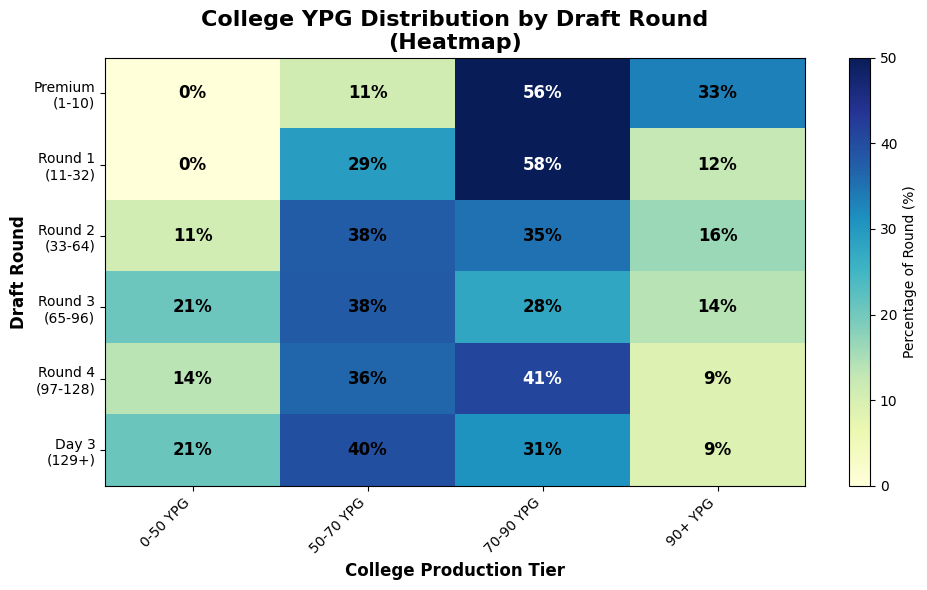

In [15]:
# Set up the plot - JUST THE HEATMAP
fig, ax = plt.subplots(figsize=(10, 6))

# Heatmap of Percentages
im = ax.imshow(pivot_percent.values, cmap='YlGnBu', aspect='auto', vmin=0, vmax=50)

# Customize heatmap
ax.set_xlabel('College Production Tier', fontsize=12, fontweight='bold')
ax.set_ylabel('Draft Round', fontsize=12, fontweight='bold')
ax.set_title('College YPG Distribution by Draft Round\n(Heatmap)', fontsize=16, fontweight='bold')
ax.set_xticks(np.arange(len(ypg_order)))
ax.set_yticks(np.arange(len(pick_order)))
ax.set_xticklabels(ypg_order, rotation=45, ha='right')
ax.set_yticklabels(['Premium\n(1-10)', 'Round 1\n(11-32)', 'Round 2\n(33-64)', 
                    'Round 3\n(65-96)', 'Round 4\n(97-128)', 'Day 3\n(129+)'])

# Add percentage labels in heatmap cells
for i in range(len(pick_order)):
    for j in range(len(ypg_order)):
        text = ax.text(j, i, f'{pivot_percent.iloc[i, j]:.0f}%',
                       ha='center', va='center', fontsize=12, 
                       fontweight='bold', color='black' if pivot_percent.iloc[i, j] < 40 else 'white')

plt.colorbar(im, ax=ax, label='Percentage of Round (%)')
plt.tight_layout()
plt.savefig('college_ypg_by_draft_range_heatmap.png', dpi=300, bbox_inches='tight')
plt.show()

### Key Takeaways: College Production vs. Draft Position

After normalizing for the number of picks in each round, five clear patterns emerge about how college production relates to draft position:

**1. The First-Round Threshold: 70+ YPG**
The clearest signal in the data: if you want to be a first-round lock, you need to average over 70 yards per game in college. 89% of top-10 picks and 70% of late-first picks hit this mark. After Round 1, that number drops to around 50% or below.

**2. Elite Producers (90+ YPG) Are Concentrated at the Top**
One-third of premium picks come from this tier, compared to just 9-16% in later rounds. Elite production gets you drafted early—but interestingly, most top picks still come from lower tiers.

**3. The 50-70 YPG Baseline**
From Round 2 through Day 3, roughly 38% of players in *every* round come from this "Good" production tier. Solid college production is the price of admission to the draft, but it doesn't determine your round.

**4. Round 4: The Value Sweet Spot?**
Round 4 has a surprising spike in 70-90 YPG producers (41%)—higher than Rounds 2, 3, or 5-7. This suggests teams are finding "great college producers" who fell due to other factors (injuries, athletic testing, character concerns, etc.) that we haven't measured yet.

**5. The Sub-50 YPG Ceiling**
Zero sub-50 YPG producers were drafted in Round 1, and they never exceed 21% of any round. Very low college production won't eliminate you, but it creates a firm ceiling on draft stock.

**The Bottom Line:** College production gets you in the door, but it doesn't determine your seat at the table. The 50-70 YPG baseline is consistent across almost every round—meaning something else is driving those final draft-day decisions.

**Next Up:** In Notebook 03, I'll combine college production metrics (YPG, YPC, TDs) with athletic testing data (40 time) to build a more complete picture of what actually drives draft position.

***
## LINKS <br>
#### [PORTFOLIO](https://quinng8.github.io/nfl-draft-analytics/)
#### [Combine Athleticism Scatter Plot](https://quinng8.github.io/nfl-draft-analytics/03_combine_scatter.html)